In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import json
import os

In [2]:
import os
import numpy as np

In [3]:
total_examples = 100
round = 100

In [4]:
def read_results(path, round):
    results = {}
    for result in os.listdir(path):
        if result.endswith(f'_{round}.json'):
            with open(os.path.join(path, result), 'r') as f:
                data = json.load(f)
            
            client = result.split('client_')[-1].split('_')[0]

            if client not in results:
                results[client] = data["rouge1"] * (data["dataset_length"] / total_examples)
            else:
                results[client] += data["rouge1"] * (data["dataset_length"] / total_examples)
    return results

Text(0.5, 1.0, 'Llama 1B Results')

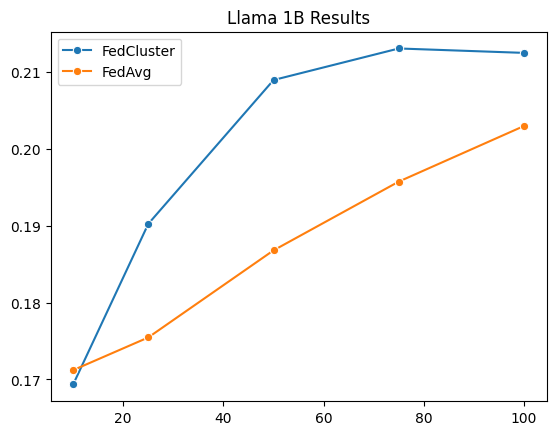

In [5]:
path_cluster = 'output/flower_experiments/Llama-3.2-1B/flower_test_clustered_aya_dataset_clustered_c10s10_i10_b16a1_l1024_r8a16_20250924152948/evals'
path_fedavg =  'output/flower_experiments/Llama-3.2-1B/flower_test_fedavg_aya_dataset_clustered_c10s10_i10_b16a1_l1024_r8a16_20250927165747/evals'
rounds = [10,25,50,75,100]

means_cluster = []
means_fedavg = []

for r in rounds:
    results_cluster = read_results(path_cluster, r)
    results_fedavg = read_results(path_fedavg, r)

    mean_all_cluster = np.mean(list(results_cluster.values()))
    mean_all_fedavg = np.mean(list(results_fedavg.values()))

    means_cluster.append(mean_all_cluster)
    means_fedavg.append(mean_all_fedavg)

sns.lineplot(x=rounds, y=means_cluster, label='FedCluster', marker='o')
sns.lineplot(x=rounds, y=means_fedavg, label='FedAvg', marker='o')
plt.title('Llama 1B Results')

In [6]:
path = 'output/flower_experiments/Llama-3.2-1B/flower_test_clustered_aya_dataset_clustered_c10s10_i10_b16a1_l1024_r8a16_20250924152948/clusters_round1.npy'


In [7]:
import numpy as np
np.load(path, allow_pickle=True)

array([1, 1, 5, 5, 4, 4, 2, 2, 3, 3], dtype=int32)